In [5]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from Data_Preprocessing.paths import PREPROCESSED_PATHS

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)
sns.set_style("whitegrid")

In [ ]:
DATA_PATH = PREPROCESSED_PATHS["processed_full_features"]
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)

df['real_price_lkr'] = np.exp(df['log_price'])
TARGET = "real_price_lkr"

cols_to_drop = [
    'target_volatility', 'log_return', 'log_price', 'volatility_4p', 'volatility_8p', 'volatility_12p',
    'log_return_lag1', 'log_return_lag2', 'log_return_lag4',
    'log_price_lag1', 'log_price_lag2', 'log_price_lag4',
    'Exchange_Rate', 'Exchange_Rate_lag1', 'Exchange_Rate_lag2', 'Exchange_Rate_lag4'
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop + [TARGET])
y = df[TARGET]

valid_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_idx]
y = y.loc[valid_idx]

print(f"Targeting Real Price. Mean Price: {y.mean():.2f} LKR")

Targeting Real Price. Mean Price: 165.81 LKR


Training Dates: 2017-05-28 to 2024-05-26 (293 rows)
Testing Dates: 2024-06-02 to 2025-10-26 (74 rows)


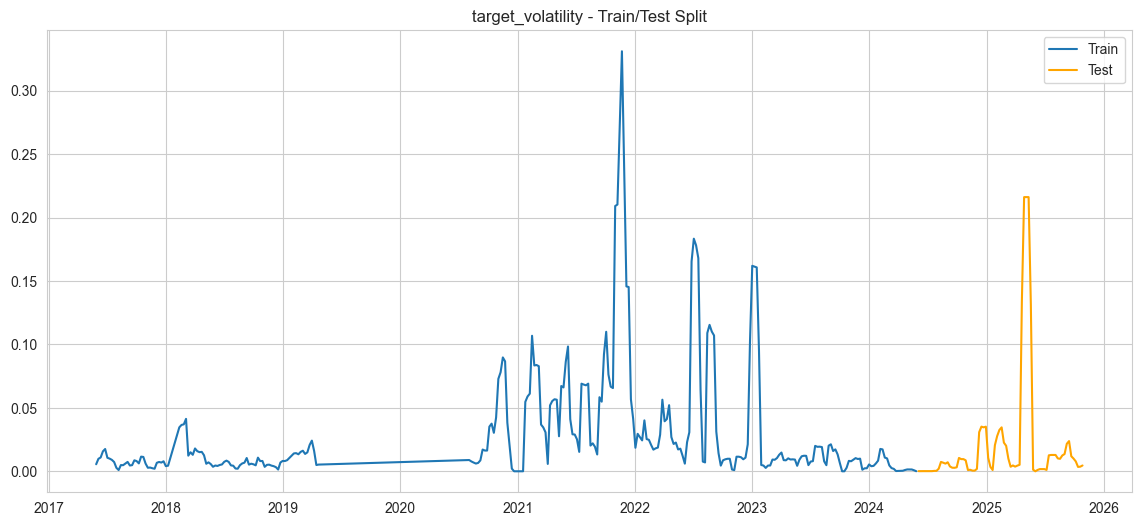

In [ ]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training Dates: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} rows)")
print(f"Testing Dates: {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} rows)")

plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test', color='orange')
plt.title(f"{TARGET} - Train/Test Split")
plt.legend()
plt.show()

Training Data: 293 rows
Testing Data: 74 rows


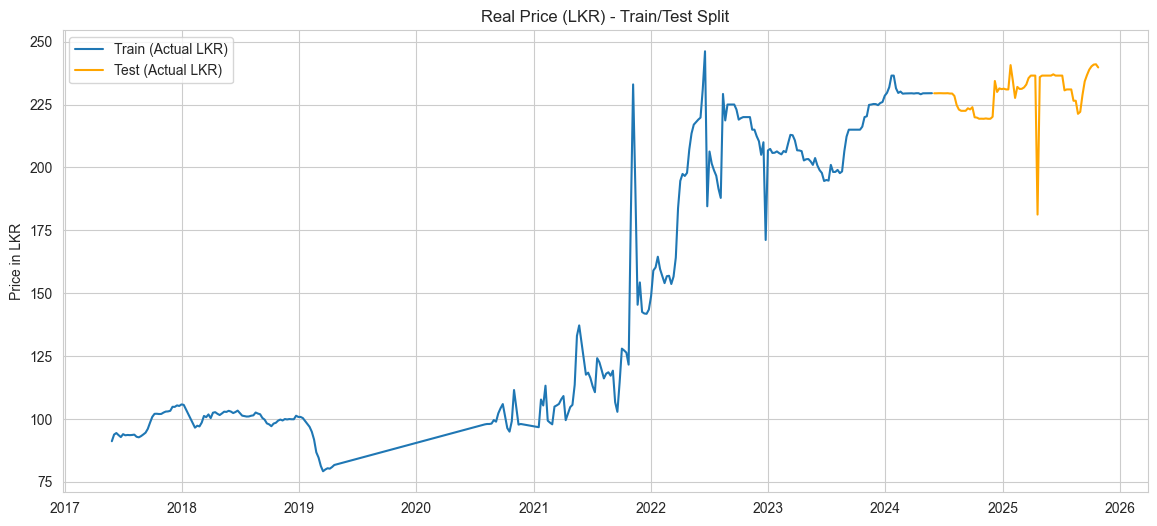

In [ ]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training Data: {len(X_train)} rows")
print(f"Testing Data: {len(X_test)} rows")

plt.plot(y_train.index, y_train, label='Train (Actual LKR)')
plt.plot(y_test.index, y_test, label='Test (Actual LKR)', color='orange')
plt.title("Real Price (LKR) - Train/Test Split")
plt.ylabel("Price in LKR")
plt.legend()
plt.show()

In [ ]:
print("Training SARIMAX Baseline Model...")

top_exog_features = ['Exchange_Rate_30d_PctChange', 'season_2021Yala', 'Temp_Min_C', 'Supply_YoY_Change_%']
top_exog_features = [c for c in top_exog_features if c in X_train.columns]

exog_train_num = X_train[top_exog_features].astype(float)
exog_test_num = X_test[top_exog_features].astype(float)
y_train_num = y_train.astype(float)
y_test_num = y_test.astype(float)

y_train_reset = y_train_num.reset_index(drop=True)
exog_train_reset = exog_train_num.reset_index(drop=True)
exog_test_reset = exog_test_num.reset_index(drop=True)

sarimax_model = SARIMAX(y_train_reset, exog=exog_train_reset, order=(1, 1, 1))
sarimax_results = sarimax_model.fit(disp=False)

start_step = len(y_train_reset)
end_step = len(y_train_reset) + len(y_test_num) - 1
sarimax_preds = sarimax_results.predict(start=start_step, end=end_step, exog=exog_test_reset)
sarimax_preds.index = y_test_num.index

mae_sarimax = mean_absolute_error(y_test_num, sarimax_preds)
mape_sarimax = mean_absolute_percentage_error(y_test_num, sarimax_preds) * 100

print(f"SARIMAX MAE:  Rs. {mae_sarimax:.2f}")
print(f"SARIMAX MAPE: {mape_sarimax:.2f}% error")

Training SARIMAX Baseline Model...
SARIMAX MAE:  Rs. 5.76
SARIMAX MAPE: 2.58% error


In [ ]:
print("Training XGBoost Regressor...")

numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns
X_train_num = X_train[numeric_cols].astype(float)
X_test_num = X_test[numeric_cols].astype(float)

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train_num, y_train_num,
    eval_set=[(X_train_num, y_train_num), (X_test_num, y_test_num)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test_num)
xgb_preds = pd.Series(xgb_preds, index=y_test.index)

mae_xgb = mean_absolute_error(y_test_num, xgb_preds)
mape_xgb = mean_absolute_percentage_error(y_test_num, xgb_preds) * 100

print(f"XGBoost MAE:  Rs. {mae_xgb:.2f}")
print(f"XGBoost MAPE: {mape_xgb:.2f}% error")

Training XGBoost Regressor...
XGBoost MAE:  Rs. 1.08
XGBoost MAPE: 0.47% error


In [ ]:
print("Training Log-Transformed XGBoost Model...")

EPSILON = 1e-4
y_train_log = np.log(y_train_num + EPSILON)
y_test_log = np.log(y_test_num + EPSILON)

xgb_log_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_log_model.fit(
    X_train_num, y_train_log,
    eval_set=[(X_train_num, y_train_log), (X_test_num, y_test_log)],
    verbose=False
)

xgb_log_preds_log = xgb_log_model.predict(X_test_num)
xgb_log_preds = np.exp(xgb_log_preds_log) - EPSILON
xgb_log_preds = np.clip(xgb_log_preds, 0, None)  
xgb_log_preds = pd.Series(xgb_log_preds, index=y_test.index)

mae_xgb_log = mean_absolute_error(y_test_num, xgb_log_preds)
rmse_xgb_log = np.sqrt(mean_squared_error(y_test_num, xgb_log_preds))

print(f"Log-XGBoost MAE:  {mae_xgb_log:.5f}")
print(f"Log-XGBoost RMSE: {rmse_xgb_log:.5f}")

Training Log-Transformed XGBoost Model...
Log-XGBoost MAE:  0.01889
Log-XGBoost RMSE: 0.04887


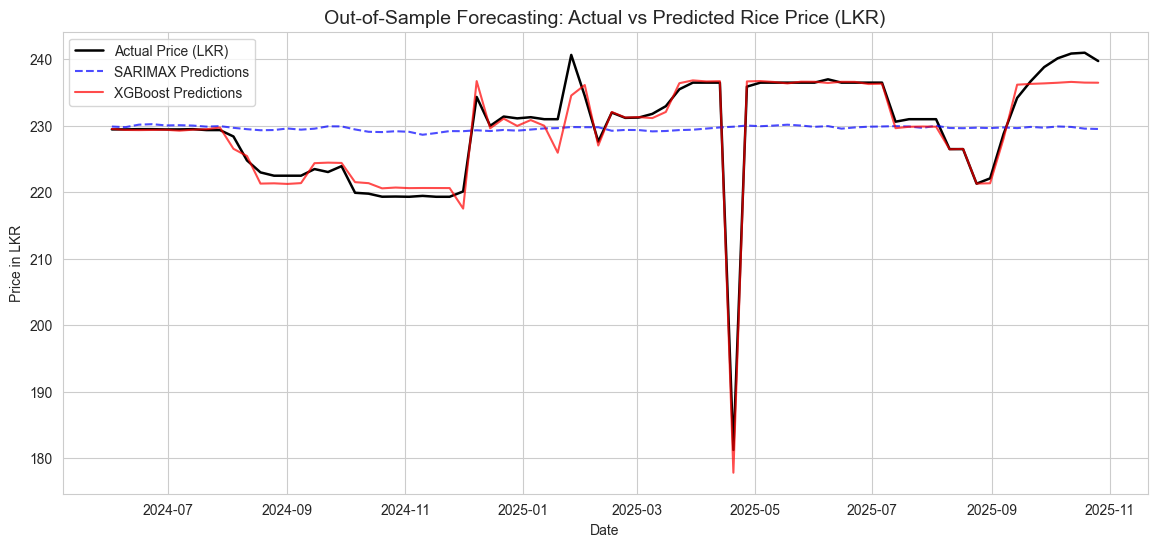

In [ ]:
plt.plot(y_test.index, y_test, label='Actual Price (LKR)', color='black', linewidth=1.8)
plt.plot(y_test.index, sarimax_preds, label='SARIMAX Predictions', color='blue', linestyle='--', alpha=0.7)
plt.plot(y_test.index, xgb_preds, label='XGBoost Predictions', color='red', alpha=0.7)

plt.title("Out-of-Sample Forecasting: Actual vs Predicted Rice Price (LKR)", fontsize=14)
plt.ylabel("Price in LKR")
plt.xlabel("Date")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
# Log-Transformed XGBoost on Real Prices
print("Training Log-Transformed XGBoost Regressor...")

y_train_log = np.log(y_train_num)
y_test_log = np.log(y_test_num)

xgb_log_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_log_model.fit(
    X_train_num, y_train_log,
    eval_set=[(X_train_num, y_train_log), (X_test_num, y_test_log)],
    verbose=False
)

xgb_log_preds_raw = xgb_log_model.predict(X_test_num)
xgb_log_preds = np.exp(xgb_log_preds_raw) 
xgb_log_preds = pd.Series(xgb_log_preds, index=y_test.index)

mae_xgb_log = mean_absolute_error(y_test_num, xgb_log_preds)
mape_xgb_log = mean_absolute_percentage_error(y_test_num, xgb_log_preds) * 100

print(f"Log-XGBoost MAE:  Rs. {mae_xgb_log:.2f}")
print(f"Log-XGBoost MAPE: {mape_xgb_log:.2f}% error")

Training Log-Transformed XGBoost Regressor...
Log-XGBoost MAE:  Rs. 1.26
Log-XGBoost MAPE: 0.55% error


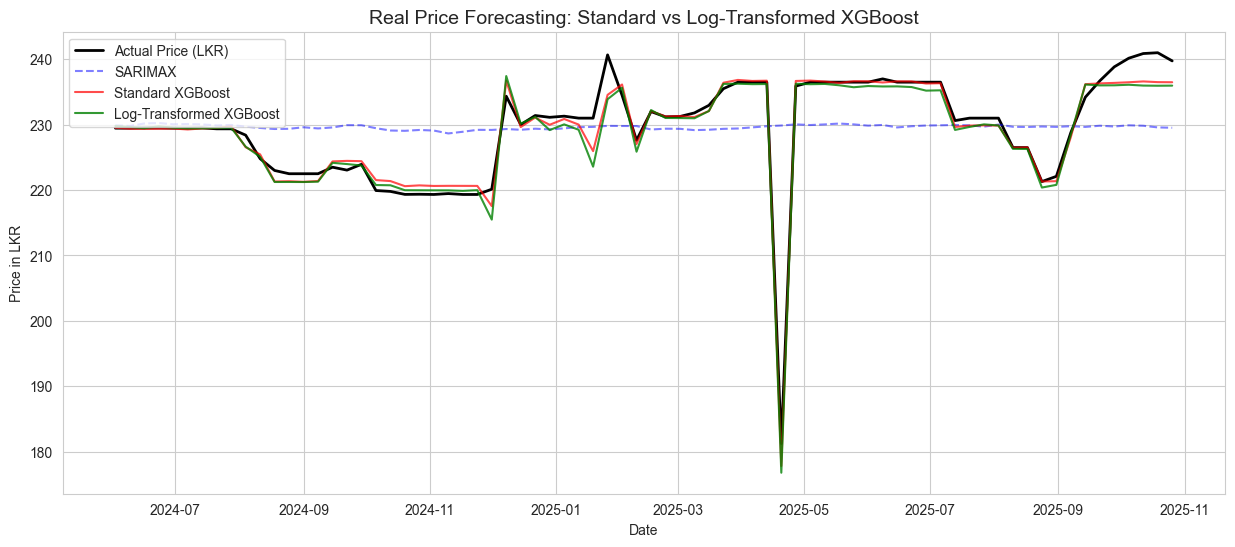

In [ ]:
# Visualizing Standard vs Log-Transformed XGBoost
plt.figure(figsize=(15, 6))

plt.plot(y_test.index, y_test, label='Actual Price (LKR)', color='black', linewidth=2)

plt.plot(y_test.index, sarimax_preds, label='SARIMAX', color='blue', linestyle='--', alpha=0.5)
plt.plot(y_test.index, xgb_preds, label='Standard XGBoost', color='red', alpha=0.7, linewidth=1.5)
plt.plot(y_test.index, xgb_log_preds, label='Log-Transformed XGBoost', color='green', alpha=0.8, linewidth=1.5)

plt.title("Real Price Forecasting: Standard vs Log-Transformed XGBoost", fontsize=14)
plt.ylabel("Price in LKR")
plt.xlabel("Date")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()